Analyzes the outputs in `/Users/nathanouyang/LSEM/scr/experiments_script/data/experiment_harness` and plots method performance versus sample size

Analysis uses `raw_results.csv` when available 

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Config
RUN_DIR = Path('data') / 'experiment_20260427_121645_perfect_logB'

# Optional filters. Leave as None to aggregate over that field.
FILTERS = {
    'n_nodes': None,
    'edge_prob': None,
    'noise_mode': None,
    'noise_label': None,
    'gaussian_ratio': None,
    'tdistr': None,
    'binary_code_mode': None,
    'intervention_model': None,
}

# When True, plot one 3x2 figure per value of FACET_BY.
FACET_BY = 'noise_label'
PLOT_SEPARATE_FACETS = True


In [3]:
SUMMARY_GROUP_COLUMNS = [
    'run_name',
    'method',
    'input_kind',
    'output_kind',
    'n_nodes',
    'sample_size_per_env',
    'observational_sample_size',
    'edge_prob',
    'binary_code_mode',
    'binary_code_source',
    'n_environments',
    'intervention_model',
    'noise_mode',
    'noise_label',
    'gaussian_ratio',
    'tdistr',
    'mix_alpha',
]

METRICS_TO_PLOT = [
    ('runtime_sec_mean', 'runtime_sec_std', 'Runtime (sec)'),
    ('frob_error_lambda_mean', 'frob_error_lambda_std', 'Relative Frob Error'),
    ('f1_score_mean', 'f1_score_std', 'F1 Score'),
    ('tpr_mean', 'tpr_std', 'TPR'),
    ('shd_mean', 'shd_std', 'SHD'),
    ('success_rate', None, 'Success Rate'),
]


def load_raw_results(run_dir: Path) -> pd.DataFrame:
    raw_path = run_dir / 'raw_results.csv'
    if not raw_path.exists():
        raise FileNotFoundError(f'Missing raw_results.csv in {run_dir}')
    return pd.read_csv(raw_path)


def build_summary_from_raw(results_df: pd.DataFrame) -> pd.DataFrame:
    if results_df.empty:
        return pd.DataFrame()

    summary = (
        results_df.groupby(SUMMARY_GROUP_COLUMNS, dropna=False)
        .agg(
            n_rows=('method', 'size'),
            n_success=('status', lambda values: int(np.sum(values == 'ok'))),
            runtime_sec_mean=('runtime_sec', 'mean'),
            runtime_sec_std=('runtime_sec', 'std'),
            frob_error_lambda_mean=('frob_error_lambda', 'mean'),
            frob_error_lambda_std=('frob_error_lambda', 'std'),
            f1_score_mean=('f1_score', 'mean'),
            f1_score_std=('f1_score', 'std'),
            tpr_mean=('tpr', 'mean'),
            tpr_std=('tpr', 'std'),
            shd_mean=('shd', 'mean'),
            shd_std=('shd', 'std'),
        )
        .reset_index()
    )
    summary['success_rate'] = summary['n_success'] / summary['n_rows']
    return summary


def apply_filters(df: pd.DataFrame, filters: dict, method_names=None) -> pd.DataFrame:
    filtered = df.copy()
    if method_names is not None:
        filtered = filtered[filtered['method'].isin(method_names)]

    for column, value in filters.items():
        if value is not None:
            filtered = filtered[filtered[column] == value]
    return filtered


def summarize_for_plot(raw_df: pd.DataFrame, filters: dict, method_names=None, aggregate_over=None) -> pd.DataFrame:
    filtered = apply_filters(raw_df, filters=filters, method_names=method_names)
    if filtered.empty:
        return pd.DataFrame()

    group_columns = ['method', 'sample_size_per_env']
    if aggregate_over is not None:
        group_columns = ['method', 'sample_size_per_env', aggregate_over]

    summary = (
        filtered.groupby(group_columns, dropna=False)
        .agg(
            n_rows=('method', 'size'),
            n_success=('status', lambda values: int(np.sum(values == 'ok'))),
            runtime_sec_mean=('runtime_sec', 'mean'),
            runtime_sec_std=('runtime_sec', 'std'),
            frob_error_lambda_mean=('frob_error_lambda', 'mean'),
            frob_error_lambda_std=('frob_error_lambda', 'std'),
            f1_score_mean=('f1_score', 'mean'),
            f1_score_std=('f1_score', 'std'),
            tpr_mean=('tpr', 'mean'),
            tpr_std=('tpr', 'std'),
            shd_mean=('shd', 'mean'),
            shd_std=('shd', 'std'),
        )
        .reset_index()
    )
    summary['success_rate'] = summary['n_success'] / summary['n_rows']
    return summary.sort_values(group_columns)


def plot_metric_grid(summary_df: pd.DataFrame, title_suffix: str = '', show_error_bars: bool = False) -> None:
    if summary_df.empty:
        raise ValueError('No rows left to plot after filtering.')

    methods = summary_df['method'].dropna().unique().tolist()
    sample_sizes = sorted(summary_df['sample_size_per_env'].dropna().unique().tolist())
    positive_sizes = [s for s in sample_sizes if s > 0]
    if not positive_sizes:
        raise ValueError('sample_size_per_env must contain positive values for log-scale plotting.')
    xmin, xmax = float(min(positive_sizes)), float(max(positive_sizes))
    n_ticks = min(7, len(positive_sizes))
    xticks = np.unique(np.round(np.geomspace(xmin, xmax, num=n_ticks)).astype(int))

    marker_cycle = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', '<', '>', 'h', '8']
    marker_map = {method_name: marker_cycle[idx % len(marker_cycle)] for idx, method_name in enumerate(methods)}

    fig, axes = plt.subplots(3, 2, figsize=(14, 14), sharex=True)
    axes = axes.ravel()

    for ax, (metric_col, std_col, title) in zip(axes, METRICS_TO_PLOT):
        for method_name in methods:
            method_df = summary_df[summary_df['method'] == method_name].sort_values('sample_size_per_env')
            if method_df.empty:
                continue

            x = method_df['sample_size_per_env'].to_numpy()
            y = method_df[metric_col].to_numpy()
            marker = marker_map[method_name]
            if show_error_bars and std_col is not None and std_col in method_df.columns:
                yerr = method_df[std_col].fillna(0).to_numpy()
                ax.errorbar(x, y, yerr=yerr, marker=marker, capsize=3, linewidth=2, label=method_name)
            else:
                ax.plot(x, y, marker=marker, linewidth=2, label=method_name)


        ax.set_title(title)
        ax.set_xlabel('Sample Size Per Environment (log10 scale)')
        ax.set_xscale('log', base=10)
        ax.set_xlim(xmin * 0.95, xmax * 1.05)
        ax.set_xticks(xticks)
        ax.set_xticklabels([f'{int(s):,}' for s in xticks], rotation=30, ha='right')
        ax.tick_params(axis='x', labelbottom=True)
        ax.grid(True, alpha=0.3)

    axes[0].legend(loc='best')
    fig.suptitle(f'Method Performance vs Sample Size{title_suffix}', fontsize=16)
    fig.tight_layout()
    plt.show()


In [ ]:

raw_df = load_raw_results(RUN_DIR)
summary_df = build_summary_from_raw(raw_df)

print(f'Run directory: {RUN_DIR}')
print(f'Raw rows: {len(raw_df)}')
print(f'Summary rows: {len(summary_df)}')
print('Methods:', sorted(raw_df['method'].dropna().unique().tolist()))
print('Sample sizes:', sorted(raw_df['sample_size_per_env'].dropna().unique().tolist()))
print('Noise labels:', sorted(raw_df['noise_label'].dropna().unique().tolist()))

In [ ]:
settings_overview = {
    'methods': sorted(raw_df['method'].dropna().unique().tolist()),
    'n_nodes': sorted(raw_df['n_nodes'].dropna().unique().tolist()),
    'edge_prob': sorted(raw_df['edge_prob'].dropna().unique().tolist()),
    'binary_code_mode': sorted(raw_df['binary_code_mode'].dropna().unique().tolist()),
    'intervention_model': sorted(raw_df['intervention_model'].dropna().unique().tolist()),
    'noise_mode': sorted(raw_df['noise_mode'].dropna().unique().tolist()),
    'noise_label': sorted(raw_df['noise_label'].dropna().unique().tolist()),
    'gaussian_ratio': sorted(raw_df['gaussian_ratio'].dropna().unique().tolist()),
    'tdistr': sorted(raw_df['tdistr'].dropna().unique().tolist()),
}

for key, values in settings_overview.items():
    print(f'{key}: {values}')

In [ ]:
METHOD_NAMES = raw_df['method'].dropna().unique().tolist()


In [11]:
plot_df = summarize_for_plot(
    raw_df,
    filters=FILTERS,
    method_names=METHOD_NAMES,
    aggregate_over=None if PLOT_SEPARATE_FACETS else None,
)

if plot_df.empty:
    raise ValueError('No rows left after applying the current filters.')

# plot_df.head(20)

In [9]:
def plot_metric_grid(summary_df: pd.DataFrame, title_suffix: str = '') -> None:
    if summary_df.empty:
        raise ValueError('No rows left to plot after filtering.')

    methods = summary_df['method'].dropna().unique().tolist()
    sample_sizes = sorted(summary_df['sample_size_per_env'].dropna().unique().tolist())
    positive_sizes = [s for s in sample_sizes if s > 0]
    if not positive_sizes:
        raise ValueError('sample_size_per_env must contain positive values for log-scale plotting.')
    xmin, xmax = float(min(positive_sizes)), float(max(positive_sizes))
    n_ticks = min(7, len(positive_sizes))
    xticks = np.unique(np.round(np.geomspace(xmin, xmax, num=n_ticks)).astype(int))

    marker_cycle = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', '<', '>', 'h', '8']
    marker_map = {method_name: marker_cycle[idx % len(marker_cycle)] for idx, method_name in enumerate(methods)}

    fig, axes = plt.subplots(3, 2, figsize=(14, 14), sharex=True)
    axes = axes.ravel()

    for ax, (metric_col, std_col, title) in zip(axes, METRICS_TO_PLOT):
        is_frob_panel = (metric_col == 'frob_error_lambda_mean')
        for method_name in methods:
            method_df = summary_df[summary_df['method'] == method_name].sort_values('sample_size_per_env')
            if method_df.empty:
                continue

            x = method_df['sample_size_per_env'].to_numpy()
            y = method_df[metric_col].to_numpy()
            marker = marker_map[method_name]

            show_err = (
                is_frob_panel
                and std_col is not None
                and std_col in method_df.columns
            )
            if show_err:
                # SEM = std / sqrt(n) for uncertainty around the mean
                n = method_df['n_rows'].clip(lower=1).to_numpy()
                yerr = method_df[std_col].fillna(0).to_numpy() / np.sqrt(n)
                ax.errorbar(x, y, yerr=yerr, marker=marker, capsize=3, linewidth=2, label=method_name)
            else:
                ax.plot(x, y, marker=marker, linewidth=2, label=method_name)

        ax.set_title(title)
        ax.set_xlabel('Sample Size Per Environment (log10 scale)')
        ax.set_xscale('log', base=10)
        ax.set_xlim(xmin * 0.95, xmax * 1.05)
        ax.set_xticks(xticks)
        ax.set_xticklabels([f'{int(s):,}' for s in xticks], rotation=30, ha='right')
        ax.tick_params(axis='x', labelbottom=True)
        ax.grid(True, alpha=0.3)

    axes[0].legend(loc='best')
    fig.suptitle(f'Method Performance vs Sample Size{title_suffix}', fontsize=16)
    fig.tight_layout()
    plt.show()



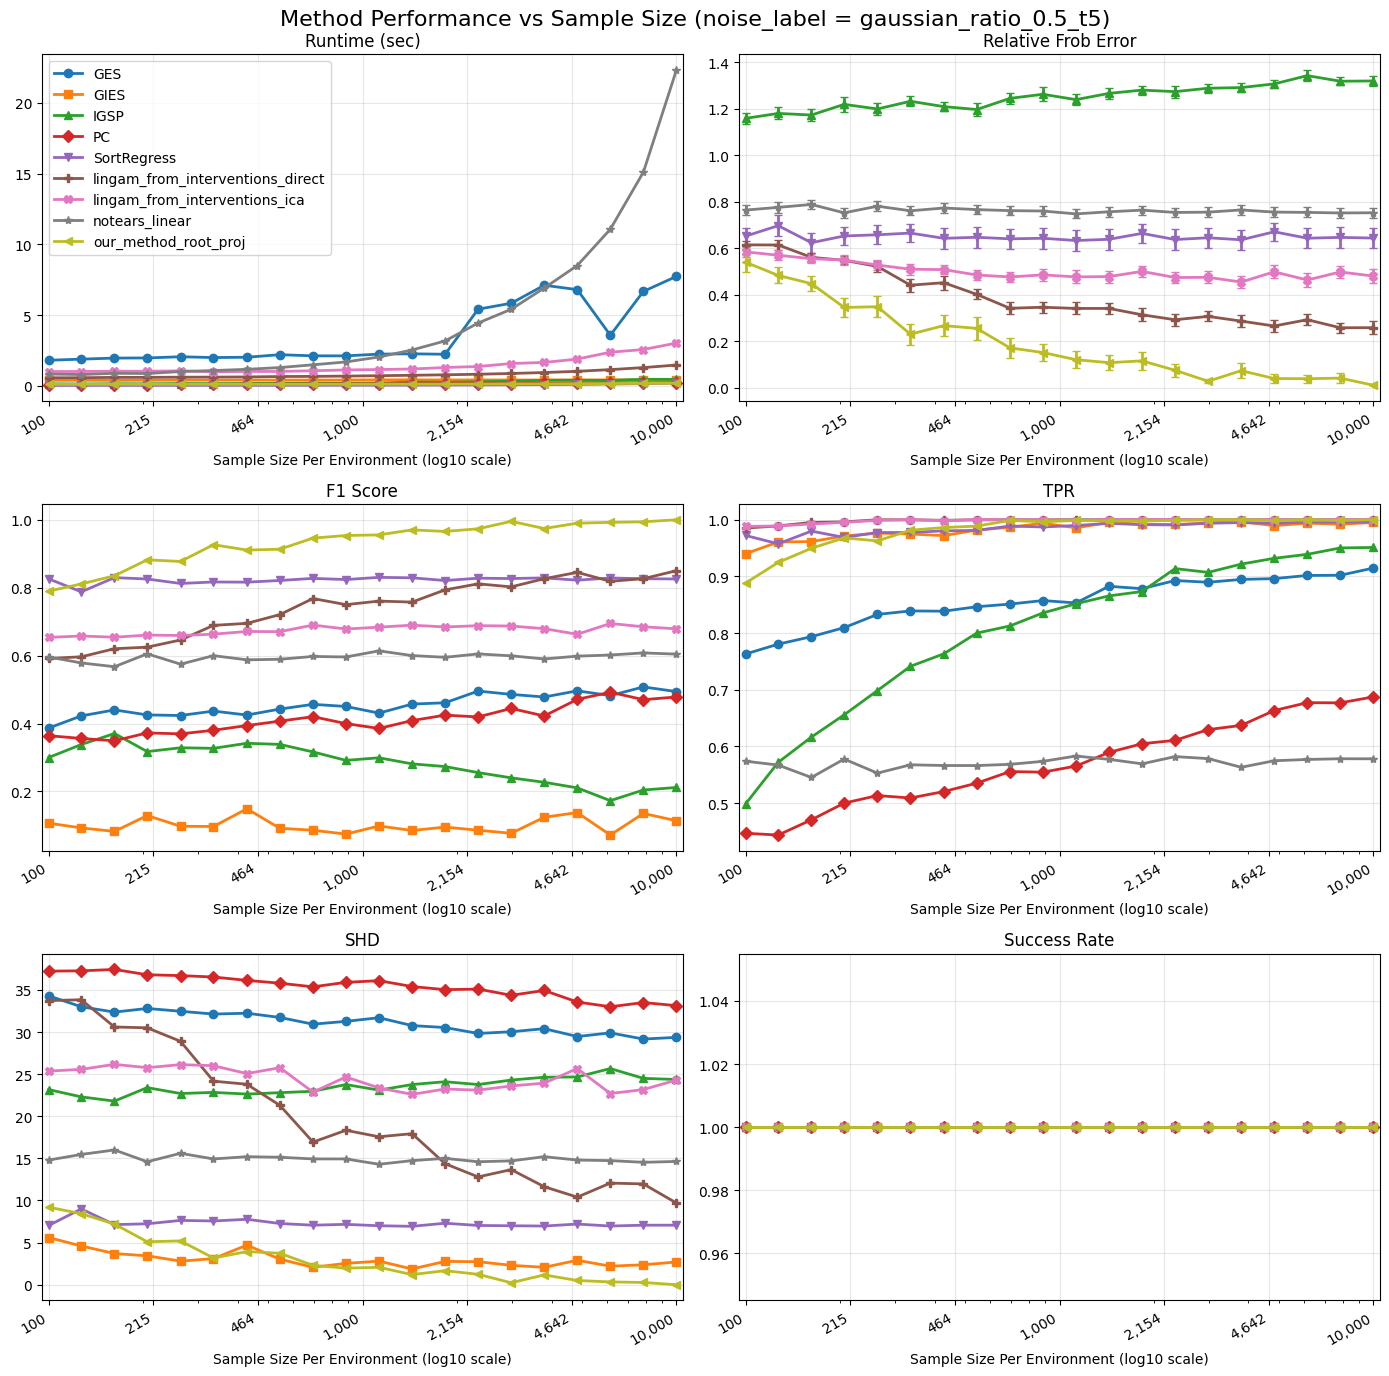

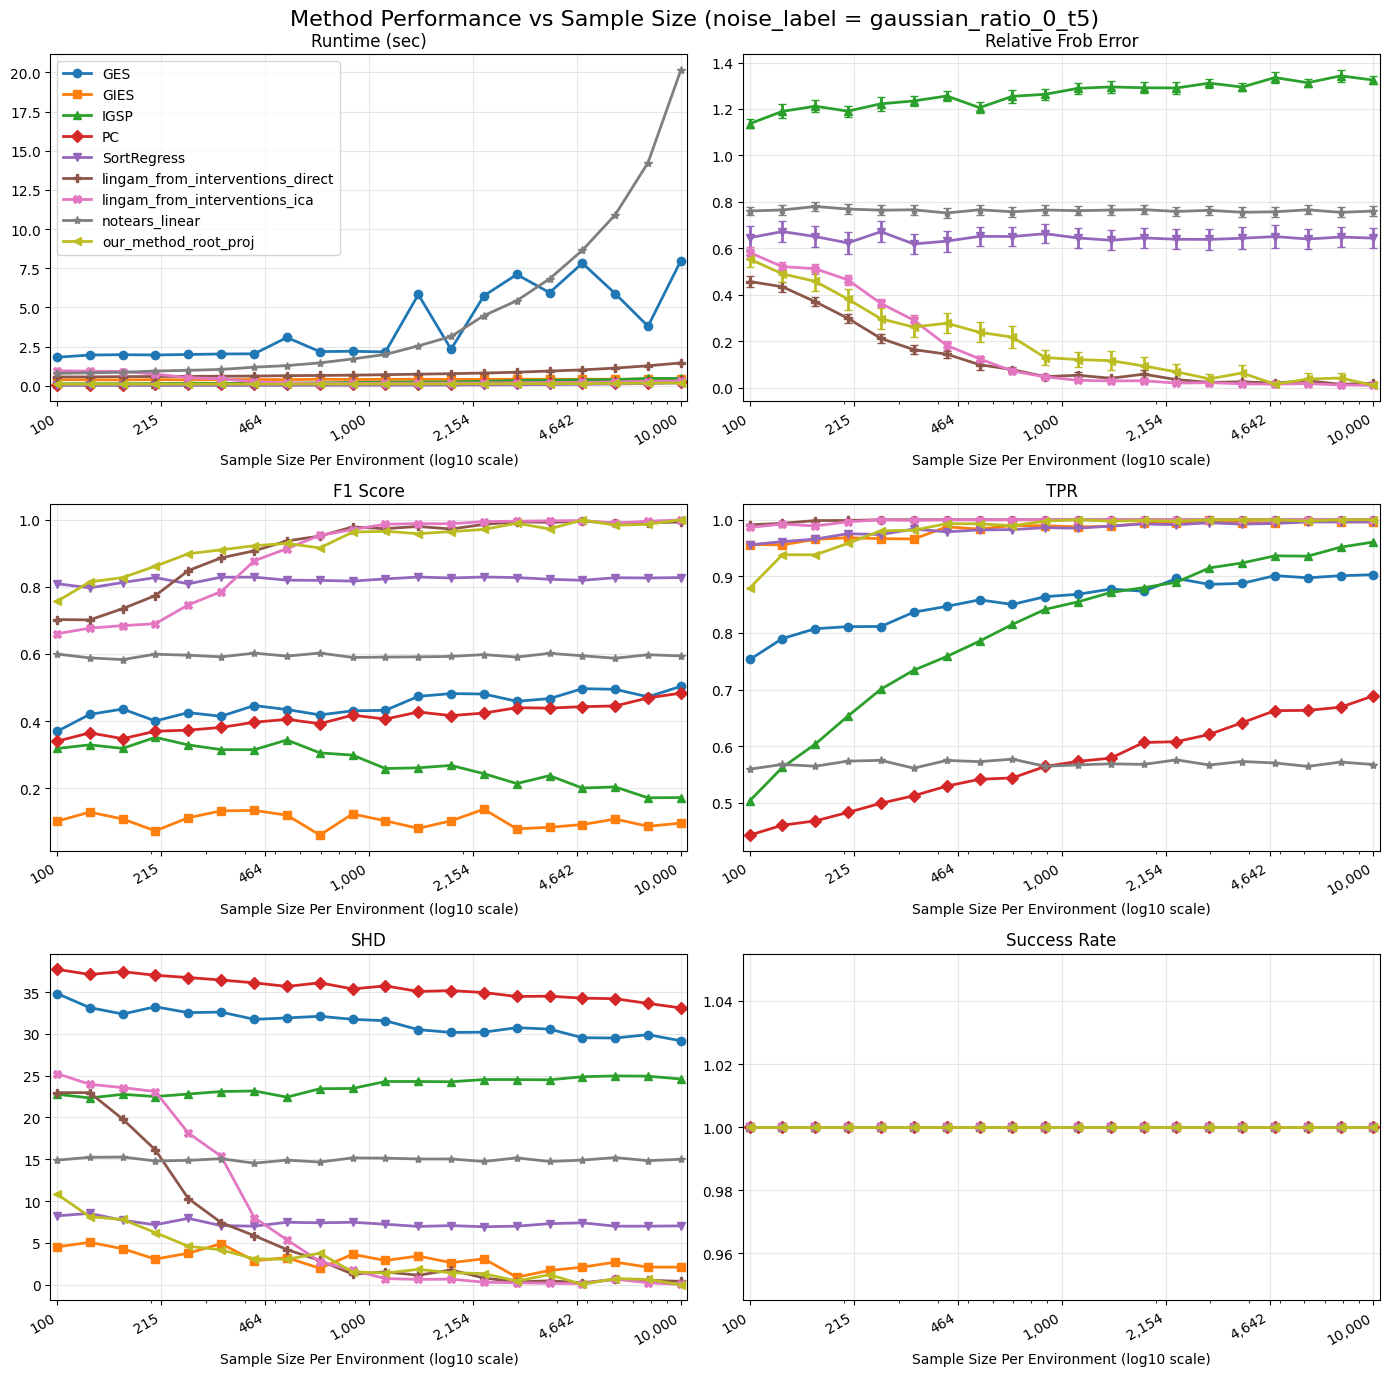

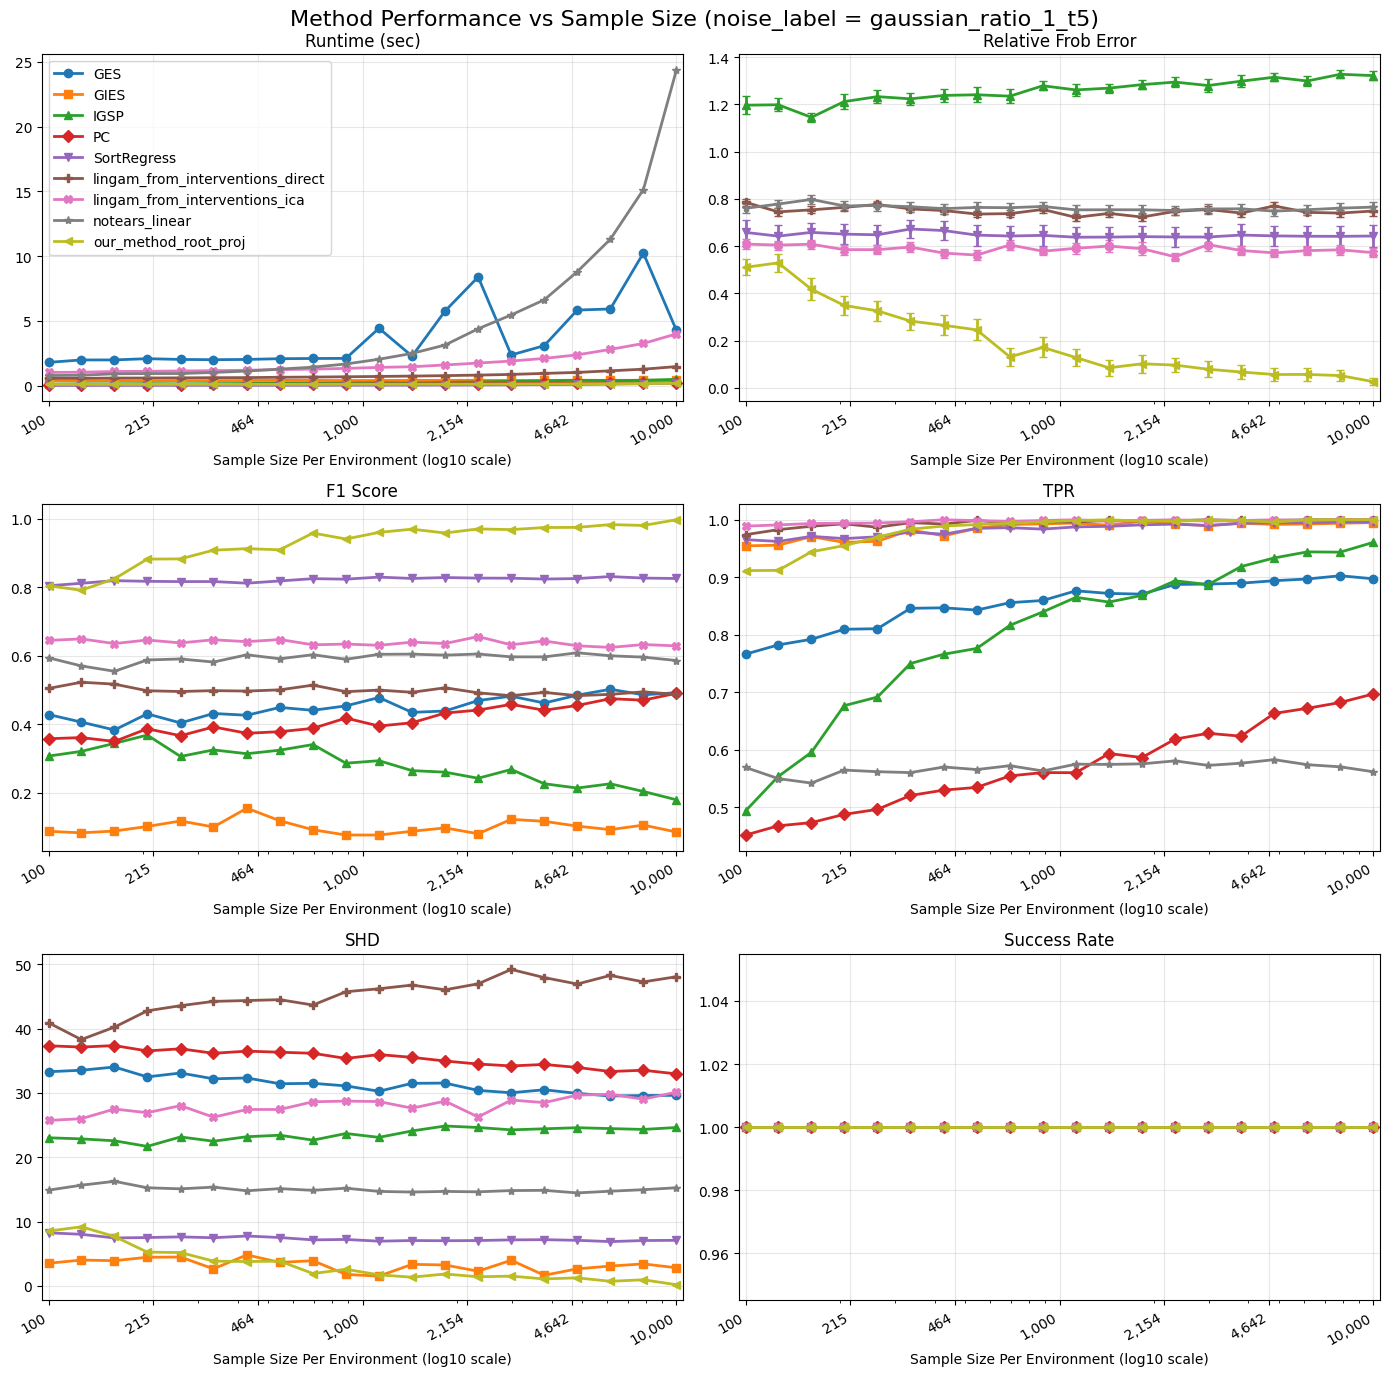

In [10]:
if not PLOT_SEPARATE_FACETS:
    plot_metric_grid(plot_df)
else:
    facet_values = sorted(raw_df[FACET_BY].dropna().unique().tolist())
    for facet_value in facet_values:
        facet_filters = dict(FILTERS)
        facet_filters[FACET_BY] = facet_value
        facet_df = summarize_for_plot(raw_df, filters=facet_filters, method_names=METHOD_NAMES)
        if not facet_df.empty:
            plot_metric_grid(facet_df, title_suffix=f' ({FACET_BY} = {facet_value})')